In [3]:
import os
import torch
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.metrics import precision_score, recall_score, f1_score

In [4]:
# =========================
# CONFIG
# =========================
IMAGE_DIR = "/kaggle/input/datasets/shivvvm/coastline-segmentationgee-masks-dataset/dataset/images"
MASK_DIR  = "/kaggle/input/datasets/shivvvm/coastline-segmentationgee-masks-dataset/dataset/masks"
MODEL_PATH = "/kaggle/input/datasets/shivvvm/unet-model-20-epoch-weights/UNet_dense_GEE_20_epoch_0_with_diff_kernels"

IMG_SIZE = 512
OUTPUT_DIR = "/kaggle/working/predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
import tensorflow as tf
from keras.layers import TFSMLayer
from keras import Model

tfsm_layer = TFSMLayer(MODEL_PATH, call_endpoint='serving_default')

# FIXED INPUT SHAPE
inputs = tf.keras.Input(shape=(512, 512, 1))

outputs = tfsm_layer(inputs)

# If output is dict → extract tensor
if isinstance(outputs, dict):
    outputs = list(outputs.values())[0]

model = Model(inputs, outputs)

Global Average Dice Evaluation

In [4]:
def compute_metrics(y_true, y_pred):
    # =========================
    # Ensure binary + integer
    # =========================
    y_true = (y_true > 0).astype(np.uint8).flatten()
    y_pred = (y_pred > 0).astype(np.uint8).flatten()

    # =========================
    # SKLEARN METRICS
    # =========================
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    # =========================
    # CUSTOM METRICS
    # =========================
    intersection = np.sum(y_true * y_pred)
    sum_true = np.sum(y_true)
    sum_pred = np.sum(y_pred)

    # Dice
    if (sum_true + sum_pred) == 0:
        dice = 1.0   # both empty → perfect match
    else:
        dice = (2.0 * intersection) / (sum_true + sum_pred)

    # IoU
    union = sum_true + sum_pred - intersection
    if union == 0:
        iou = 1.0
    else:
        iou = intersection / union

    return precision, recall, f1, dice, iou

In [9]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("rasterio").setLevel(logging.ERROR)

from tqdm import tqdm   # Progress bar

# =========================
# INFERENCE LOOP (FIXED)
# =========================
all_metrics = []

image_files = sorted(os.listdir(IMAGE_DIR))

# Progress bar added here
for name in tqdm(image_files, desc="Processing Tiles", unit="tile"):

    img_path = os.path.join(IMAGE_DIR, name)
    mask_path = os.path.join(MASK_DIR, name)

    # =========================
    # READ IMAGE
    # =========================
    with rasterio.open(img_path) as src:
        image = src.read()

    image = np.transpose(image, (1,2,0)).astype(np.float32)

    # =========================
    # FIX 1: Convert to 1 channel
    # =========================
    if image.shape[2] > 1:
        image = image[:,:,0]

    # =========================================================
    # NEW: VIEWING NORMALIZATION ONLY (DO NOT USE FOR MODEL)
    # =========================================================
    # This is ONLY for visualization/saving in predictions.zip
    view_image = image.copy()

    p2, p98 = np.percentile(view_image, (2, 98))
    view_image = np.clip(view_image, p2, p98)
    view_image = (view_image - p2) / (p98 - p2 + 1e-8)

    # =========================
    # ORIGINAL MODEL NORMALIZATION
    # (UNCHANGED)
    # =========================
    image = np.log1p(image)
    image = (image - 0.166985) / 0.160023

    # =========================
    # CHECK NaN IN INPUT
    # =========================
    if np.isnan(image).any():
        print(f"NaN in input image: {name}")
        continue

    # =========================
    # RESIZE → 512x512
    # =========================
    image_resized = tf.image.resize(
        image[..., np.newaxis],
        (512, 512)
    )

    image_resized = np.expand_dims(image_resized, axis=0)

    # =========================
    # PREDICT
    # =========================
    pred = model.predict(image_resized, verbose=0)

    # =========================
    # CHECK NaN IN PREDICTION
    # =========================
    if isinstance(pred, dict):
        pred = list(pred.values())[0]

    if np.isnan(pred).any():
        print(f"NaN in prediction: {name}")
        continue

    pred = pred[0, :, :, 0]

    # =========================
    # BINARY MASK
    # =========================
    # print("Pred min/max:", pred.min(), pred.max())

    pred_bin = (pred > 0.85).astype(np.uint8)

    # =========================
    # LOAD GT MASK
    # =========================
    with rasterio.open(mask_path) as src:
        gt = src.read(1)

    # Resize GT
    gt = tf.image.resize(
        gt[..., np.newaxis],
        (512, 512),
        method='nearest'
    )

    gt = gt.numpy().squeeze()

    gt_bin = (gt > 0).astype(np.uint8)

    # =========================
    # SKIP EMPTY GT
    # =========================
    if np.sum(gt_bin) == 0:
        continue

    # =========================
    # METRICS
    # =========================
    metrics = compute_metrics(gt_bin, pred_bin)
    all_metrics.append(metrics)

    # =========================
    # RESIZE VIEW IMAGE FOR DISPLAY
    # =========================
    view_image_resized = tf.image.resize(
        view_image[..., np.newaxis],
        (512, 512)
    ).numpy().squeeze()

    # =========================
    # VISUALIZATION
    # =========================
    plt.figure(figsize=(12,4))

    # -------------------------------------------------
    # NORMALIZED SAR FOR VIEWING PURPOSE ONLY
    # -------------------------------------------------
    plt.subplot(1,3,1)
    plt.imshow(view_image_resized, cmap='gray')
    plt.title("SAR Image (2-98 Percentile)")

    # -------------------------------------------------
    # GT
    # -------------------------------------------------
    plt.subplot(1,3,2)
    plt.imshow(gt_bin, cmap='gray')
    plt.title("Ground Truth")

    # -------------------------------------------------
    # PREDICTION
    # -------------------------------------------------
    plt.subplot(1,3,3)
    plt.imshow(pred_bin, cmap='gray')
    plt.title("Prediction")

    plt.tight_layout()

    save_path = os.path.join(
        OUTPUT_DIR,
        name.replace(".tif", ".png")
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

print("\nInference Completed!")
print(f"Total evaluated tiles: {len(all_metrics)}")

Processing Tiles: 100%|██████████| 783/783 [12:14<00:00,  1.07tile/s]


Inference Completed!
Total evaluated tiles: 783


In [10]:
# =========================
# FINAL METRICS PRINT
# =========================

if len(all_metrics) == 0:
    print("No valid samples found (all masks empty or skipped).")
else:
    all_metrics = np.array(all_metrics)

    precision = all_metrics[:,0].mean()
    recall    = all_metrics[:,1].mean()
    f1        = all_metrics[:,2].mean()
    dice      = all_metrics[:,3].mean()
    iou       = all_metrics[:,4].mean()

    print("\n===== FINAL RESULTS =====")
    print(f"Samples used : {len(all_metrics)}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Dice         : {dice:.4f}")
    print(f"IoU          : {iou:.4f}")


===== FINAL RESULTS =====
Samples used : 783
Precision    : 0.4027
Recall       : 0.7750
F1 Score     : 0.4505
Dice         : 0.4505
IoU          : 0.4001


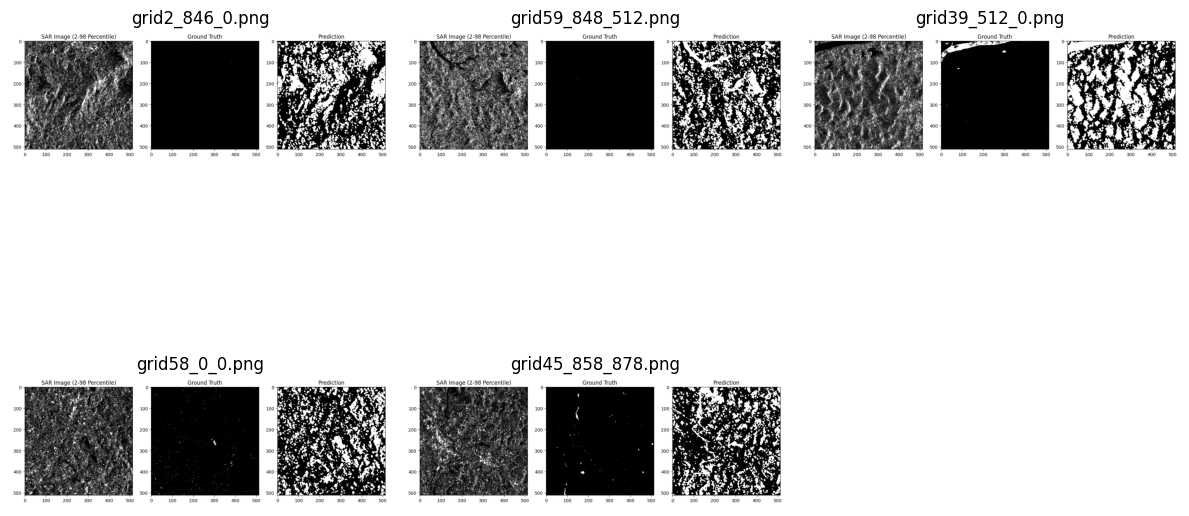

In [11]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_prediction_grid(pred_dir, num_samples=9):
    files = [f for f in os.listdir(pred_dir) if f.endswith(".png")]
    selected = random.sample(files, min(num_samples, len(files)))

    cols = 3
    rows = (len(selected) + cols - 1) // cols

    plt.figure(figsize=(12, 4 * rows))

    for i, file in enumerate(selected):
        img = Image.open(os.path.join(pred_dir, file))

        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.title(file)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

PRED_DIR = "/kaggle/working/predictions"

show_prediction_grid(PRED_DIR, num_samples=5)

In [13]:
import shutil

shutil.make_archive(
    '/kaggle/working/Unet_predictions',  # zip file name
    'zip',
    '/kaggle/working/predictions'
)

'/kaggle/working/Unet_predictions.zip'

Bucket Wise Evaluation Code

In [6]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import rasterio

# =====================================================
# CONFIG
# =====================================================
IMAGE_DIR = "/kaggle/input/datasets/shivvvm/coastline-segmentationgee-masks-dataset/dataset/images"
MASK_DIR  = "/kaggle/input/datasets/shivvvm/coastline-segmentationgee-masks-dataset/dataset/masks"

IMG_SIZE   = 512
THRESHOLD  = 0.85

# Same normalization used in inference
GLOBAL_MEAN = 0.166985
GLOBAL_STD  = 0.160023

# =====================================================
# ASSUMPTION:
# model already loaded
# =====================================================

# =====================================================
# HELPERS
# =====================================================
def load_image(path):
    with rasterio.open(path) as src:
        img = src.read()

    img = np.transpose(img, (1,2,0)).astype(np.float32)

    if img.shape[2] > 1:
        img = img[:,:,0]
    else:
        img = img.squeeze()

    img = np.nan_to_num(img)

    # log + zscore normalization
    img = np.log1p(img)
    img = (img - GLOBAL_MEAN) / (GLOBAL_STD + 1e-8)

    img = tf.image.resize(
        img[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE)
    ).numpy()

    return img


def load_mask(path):
    with rasterio.open(path) as src:
        gt = src.read(1)

    gt = tf.image.resize(
        gt[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE),
        method="nearest"
    ).numpy().squeeze()

    gt = (gt > 0).astype(np.uint8)

    return gt


def metrics(gt, pred):
    tp = np.logical_and(gt == 1, pred == 1).sum()
    tn = np.logical_and(gt == 0, pred == 0).sum()
    fp = np.logical_and(gt == 0, pred == 1).sum()
    fn = np.logical_and(gt == 1, pred == 0).sum()

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    dice      = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)
    acc       = (tp + tn) / (tp + tn + fp + fn + 1e-8)

    return tp, tn, fp, fn, precision, recall, dice, iou, acc


def assign_bucket(gt_ratio):
    if gt_ratio < 5:
        return "0-5%"
    elif gt_ratio < 20:
        return "5-20%"
    elif gt_ratio < 50:
        return "20-50%"
    elif gt_ratio < 80:
        return "50-80%"
    else:
        return "80-100%"


# =====================================================
# LOOP
# =====================================================
files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".tif") or f.endswith(".tiff")
])

rows = []

# global accumulators
G_tp = G_tn = G_fp = G_fn = 0

for idx, name in enumerate(files):

    img_path = os.path.join(IMAGE_DIR, name)
    gt_path  = os.path.join(MASK_DIR, name)

    # -------------------------
    # load image
    # -------------------------
    img = load_image(img_path)
    inp = np.expand_dims(img, axis=0)

    pred = model.predict(inp, verbose=0)

    if isinstance(pred, dict):
        pred = list(pred.values())[0]

    pred = pred[0,:,:,0]

    pred_bin = (pred > THRESHOLD).astype(np.uint8)

    # -------------------------
    # load gt
    # -------------------------
    gt = load_mask(gt_path)

    gt_ratio = gt.mean() * 100.0
    bucket = assign_bucket(gt_ratio)

    # -------------------------
    # metrics
    # -------------------------
    tp, tn, fp, fn, precision, recall, dice, iou, acc = metrics(gt, pred_bin)

    G_tp += tp
    G_tn += tn
    G_fp += fp
    G_fn += fn

    rows.append({
        "file": name,
        "bucket": bucket,
        "gt_fg_%": gt_ratio,
        "precision": precision,
        "recall": recall,
        "dice": dice,
        "iou": iou,
        "accuracy": acc
    })

    if (idx + 1) % 50 == 0:
        print(f"Processed {idx+1}/{len(files)}")

# =====================================================
# DATAFRAME
# =====================================================
df = pd.DataFrame(rows)

# =====================================================
# BUCKET SUMMARY
# =====================================================
bucket_summary = df.groupby("bucket").agg(
    samples=("file", "count"),
    mean_gt_fg=("gt_fg_%", "mean"),
    precision=("precision", "mean"),
    recall=("recall", "mean"),
    dice=("dice", "mean"),
    iou=("iou", "mean"),
    accuracy=("accuracy", "mean")
).reset_index()

# keep logical order
bucket_order = ["0-5%", "5-20%", "20-50%", "50-80%", "80-100%"]
bucket_summary["bucket"] = pd.Categorical(
    bucket_summary["bucket"],
    categories=bucket_order,
    ordered=True
)
bucket_summary = bucket_summary.sort_values("bucket")

print("\n==============================")
print("DICE / METRICS BY GT FOREGROUND BUCKET")
print("==============================")
print(bucket_summary.to_string(index=False))

# =====================================================
# GLOBAL METRICS
# =====================================================
global_precision = G_tp / (G_tp + G_fp + 1e-8)
global_recall    = G_tp / (G_tp + G_fn + 1e-8)
global_dice      = (2 * G_tp) / (2 * G_tp + G_fp + G_fn + 1e-8)
global_iou       = G_tp / (G_tp + G_fp + G_fn + 1e-8)
global_acc       = (G_tp + G_tn) / (G_tp + G_tn + G_fp + G_fn + 1e-8)

print("\n==============================")
print("GLOBAL METRICS")
print("==============================")
print(f"Samples Used : {len(df)}")
print(f"Precision    : {global_precision:.4f}")
print(f"Recall       : {global_recall:.4f}")
print(f"Dice / F1    : {global_dice:.4f}")
print(f"IoU          : {global_iou:.4f}")
print(f"Accuracy     : {global_acc:.4f}")

# =====================================================
# SAVE REPORTS
# =====================================================
df.to_csv("/kaggle/working/per_tile_bucket_metrics.csv", index=False)
bucket_summary.to_csv("/kaggle/working/bucket_summary_metrics.csv", index=False)

print("\nSaved Files:")
print("/kaggle/working/per_tile_bucket_metrics.csv")
print("/kaggle/working/bucket_summary_metrics.csv")

I0000 00:00:1778597300.286685     143 service.cc:152] XLA service 0x7d9afc021c90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778597300.286751     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778597300.286755     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778597300.822226     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778597312.549695     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Processed 50/783
Processed 100/783
Processed 150/783
Processed 200/783
Processed 250/783
Processed 300/783
Processed 350/783
Processed 400/783
Processed 450/783
Processed 500/783
Processed 550/783
Processed 600/783
Processed 650/783
Processed 700/783
Processed 750/783

DICE / METRICS BY GT FOREGROUND BUCKET
 bucket  samples  mean_gt_fg  precision   recall     dice      iou  accuracy
   0-5%      346    1.039903   0.017984 0.524139 0.033621 0.017662  0.624573
  5-20%       86   11.500576   0.235395 0.911006 0.364322 0.230070  0.626027
 20-50%       86   32.750325   0.513793 0.967348 0.660352 0.504537  0.668321
 50-80%       70   64.954278   0.768336 0.987842 0.860756 0.761218  0.793502
80-100%      195   96.781442   0.978765 0.998958 0.988440 0.977831  0.978583

GLOBAL METRICS
Samples Used : 783
Precision    : 0.5697
Recall       : 0.9872
Dice / F1    : 0.7225
IoU          : 0.5655
Accuracy     : 0.7328

Saved Files:
/kaggle/working/per_tile_bucket_metrics.csv
/kaggle/working/bucket_sum

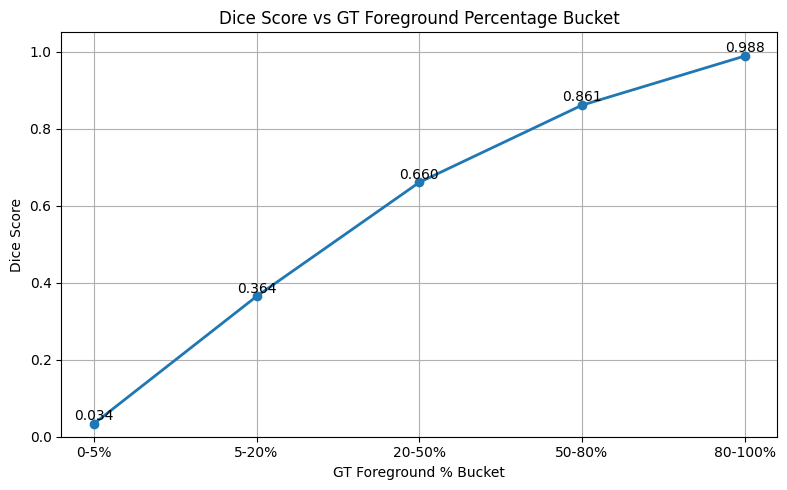

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# LOAD CSV
# =====================================================
csv_path = "/kaggle/working/bucket_summary_metrics.csv"

df = pd.read_csv(csv_path)

# =====================================================
# SORT BUCKET ORDER
# =====================================================
bucket_order = ["0-5%", "5-20%", "20-50%", "50-80%", "80-100%"]

df["bucket"] = pd.Categorical(
    df["bucket"],
    categories=bucket_order,
    ordered=True
)

df = df.sort_values("bucket")

# =====================================================
# PLOT DICE VS BUCKET
# =====================================================
plt.figure(figsize=(8,5))

plt.plot(
    df["bucket"],
    df["dice"],
    marker='o',
    linewidth=2
)

# Add value labels
for x, y in zip(df["bucket"], df["dice"]):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')

plt.xlabel("GT Foreground % Bucket")
plt.ylabel("Dice Score")
plt.title("Dice Score vs GT Foreground Percentage Bucket")

plt.ylim(0, 1.05)

plt.grid(True)

plt.tight_layout()
plt.show()